In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset desde Google Drive
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/My Drive/Anexo-CD/Datos/dataset_final_2024.csv'
df = pd.read_csv(ruta)

# Info general
df.info()
df.head()


Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26742 entries, 0 to 26741
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Nombre del Estudiante  26742 non-null  object
 1   curso                  26742 non-null  object
 2   sexo                   26742 non-null  object
 3   matricula              26742 non-null  int64 
 4   nivel                  26742 non-null  object
 5   materia                26742 non-null  object
 6   trimestre              26742 non-null  object
 7   nota                   26742 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 1.6+ MB


,Nombre del Estudiante,curso,sexo,matricula,nivel,materia,trimestre,nota
0,AYZAMA GARCIA SEBASTIAN ZABDIEL,1PRI A,M,431,Primaria,len,1T,98
1,BOADO QUIROGA CAMACHO GABRIEL,1PRI A,M,310,Primaria,len,1T,92
2,CARDOZO LUIZAGA JORGE SEBASTIAN,1PRI A,M,651,Primaria,len,1T,74
3,CERVANTES PAREDES AYELEN MIA,1PRI A,F,552,Primaria,len,1T,65
4,COCA RODRIGUEZ ALISSON GRECIA,1PRI A,F,606,Primaria,len,1T,89


In [ ]:
# Eliminar la columna del nombre del estudiante
df = df.drop(columns=["Nombre del Estudiante"], errors="ignore")

# Verificar resultado
df.head()

,curso,sexo,matricula,nivel,materia,trimestre,nota
0,1PRI A,M,431,Primaria,len,1T,98
1,1PRI A,M,310,Primaria,len,1T,92
2,1PRI A,M,651,Primaria,len,1T,74
3,1PRI A,F,552,Primaria,len,1T,65
4,1PRI A,F,606,Primaria,len,1T,89


In [ ]:
# Guardamos el dataset sin esa columna
df.to_csv("/content/drive/My Drive/Anexo-CD/Datos/dataset_2024_sin_nombres.csv", index=False)


In [ ]:
# cargamos el nuevo data set sin nombres
ruta2 = '/content/drive/My Drive/Anexos-CD/Datos/dataset_2024_sin_nombres.csv'
df2 = pd.read_csv(ruta2)
df2.info()
df2.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26742 entries, 0 to 26741
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   curso      26742 non-null  object
 1   sexo       26742 non-null  object
 2   matricula  26742 non-null  int64 
 3   nivel      26742 non-null  object
 4   materia    26742 non-null  object
 5   trimestre  26742 non-null  object
 6   nota       26742 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 1.4+ MB


,curso,sexo,matricula,nivel,materia,trimestre,nota
0,1PRI A,M,431,Primaria,len,1T,98
1,1PRI A,M,310,Primaria,len,1T,92
2,1PRI A,M,651,Primaria,len,1T,74
3,1PRI A,F,552,Primaria,len,1T,65
4,1PRI A,F,606,Primaria,len,1T,89
5,1PRI A,M,393,Primaria,len,1T,94
6,1PRI A,M,261,Primaria,len,1T,89
7,1PRI A,F,322,Primaria,len,1T,97
8,1PRI A,F,575,Primaria,len,1T,54
9,1PRI A,F,565,Primaria,len,1T,90



📊 Estadísticas descriptivas de las notas:


,nota
count,26742.000000
mean,79.897352
std,14.400446
min,1.000000
25%,70.000000
50%,82.000000
75%,91.000000
max,100.000000


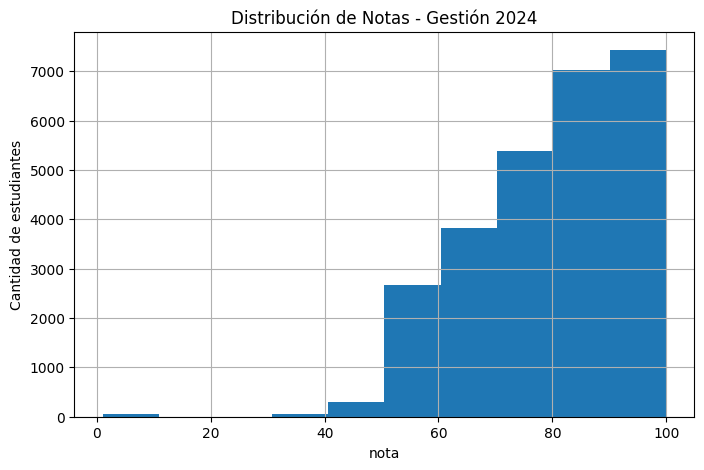

In [ ]:
# Análisis descriptivo de la columna de notas
print("\n📊 Estadísticas descriptivas de las notas:")
display(df2["nota"].describe())

# Distribución general de calificaciones
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df2["nota"].hist()
plt.title("Distribución de Notas - Gestión 2024")
plt.xlabel("nota")
plt.ylabel("Cantidad de estudiantes")
plt.show()


In [ ]:
promedio_nivel_trimestre = df2.groupby(["nivel", "trimestre"])["nota"].mean().reset_index()

print("\n📊 Promedio por nivel y trimestre:")
display(promedio_nivel_trimestre)



📊 Promedio por nivel y trimestre:


,nivel,trimestre,nota
0,Primaria,1T,83.611705
1,Primaria,2T,85.823356
2,Primaria,3T,86.502940
3,Secundaria,1T,74.714037
4,Secundaria,2T,76.111369
5,Secundaria,3T,77.112529


In [ ]:
# 1. Definir las variables de filtrado (ejemplo)
curso_objetivo = '1PRI A'
trimestre_objetivo = '1T'
materia_objetivo = 'len'
columna_notas = 'nota' # Asegúrate de que esta columna contenga valores numéricos

# 2. Filtrar el DataFrame
# Se aplica una máscara booleana para seleccionar solo las filas que cumplen
# ambas condiciones: el curso y el trimestre deseados.
df_filtrado = df2[
    (df2['curso'] == curso_objetivo) &
    (df2['trimestre'] == trimestre_objetivo) &
    (df2['materia'] == materia_objetivo)
]


# 3. Calcular la suma de las notas en la columna 'Nota'
# Se selecciona la columna de notas del DataFrame filtrado y se aplica el método .sum()
suma_total_notas = df_filtrado[columna_notas].sum() / df_filtrado['materia'].count()

# 4. Imprimir el resultado
print(f"La suma total de las notas para el curso '{curso_objetivo}' en el trimestre {trimestre_objetivo} es: {suma_total_notas}")
df_filtrado.head(10)
df_filtrado.info()
display(df_filtrado['nota'].describe())


La suma total de las notas para el curso '1PRI A' en el trimestre 1T es: 83.75862068965517
<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 28
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   curso      29 non-null     object
 1   sexo       29 non-null     object
 2   matricula  29 non-null     int64 
 3   nivel      29 non-null     object
 4   materia    29 non-null     object
 5   trimestre  29 non-null     object
 6   nota       29 non-null     int64 
dtypes: int64(2), object(5)
memory usage: 1.8+ KB


,nota
count,29.000000
mean,83.758621
std,14.019515
min,52.000000
25%,75.000000
50%,89.000000
75%,94.000000
max,99.000000


In [ ]:
#Verificamos si existen valores nulos
df2.isnull().sum()
print("Valores nulos:")

,0
curso,0
sexo,0
matricula,0
nivel,0
materia,0
trimestre,0
nota,0
